In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

!unzip -q ml-latest-small.zip

--2026-08-05 14:24:54--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  1.01MB/s    in 0.9s    

2026-08-05 14:24:56 (1.01 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



#1. Import libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

#2. Load the dataset

In [ ]:
movies=pd.read_csv("/content/ml-latest-small/movies.csv")
ratings=pd.read_csv("/content/ml-latest-small/ratings.csv")
print(movies.shape)
print(rating.shape)

(9742, 3)
(100836, 4)


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
rating.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
#check missing values
print("Movies Dataset\n")
print(movies.isnull().sum())

print("\n")

print("Ratings Dataset\n")
print(ratings.isnull().sum())

Movies Dataset

movieId    0
title      0
genres     0
dtype: int64


Ratings Dataset

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [ ]:
#basic information about my dataset
print("Number of Movies :", movies['movieId'].nunique())

print("Number of Users :", ratings['userId'].nunique())

print("Total Ratings :", ratings.shape[0])

Number of Movies : 9742
Number of Users : 610
Total Ratings : 100836


In [ ]:
#merge the movies and ratings
movie_data=pd.merge(ratings,movies,on="movieId")
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [ ]:
#random sample
movie_data.sample(10)

,userId,movieId,rating,timestamp,title,genres
75018,474,27706,3.5,1114693575,Lemony Snicket's A Series of Unfortunate Event...,Adventure|Children|Comedy|Fantasy
18096,113,3556,3.0,980051421,"Virgin Suicides, The (1999)",Drama|Romance
20274,133,253,2.0,843491249,Interview with the Vampire: The Vampire Chroni...,Drama|Horror
100026,610,7438,4.5,1493844840,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller
61766,409,1911,2.0,968978193,Dr. Dolittle (1998),Comedy
25980,181,21,2.0,845469555,Get Shorty (1995),Comedy|Crime|Thriller
96056,602,431,3.0,840876597,Carlito's Way (1993),Crime|Drama
63904,414,5293,4.0,1050766603,Changing Lanes (2002),Drama|Thriller
85598,555,2255,1.0,978823282,Young Doctors in Love (1982),Comedy
2648,19,2027,1.0,965708217,Jane Austen's Mafia! (1998),Comedy|Crime


#Exploratory data analysis


In [ ]:
#summary stats
print("Movie Data Statistics\n")

movie_data.describe()

Movie Data Statistics



,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


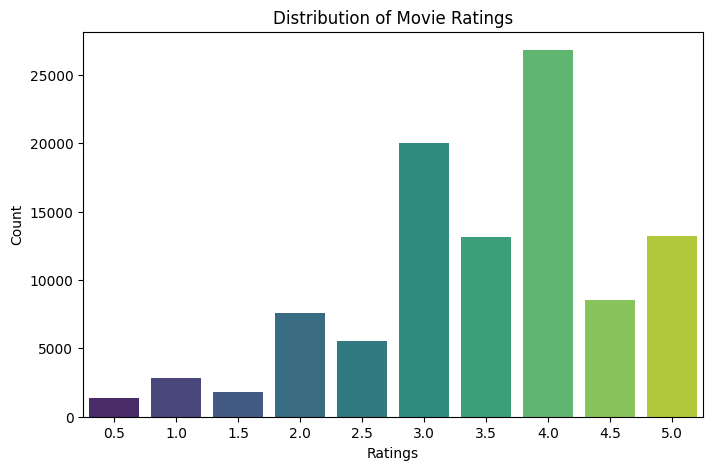

In [ ]:
#rating distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=movie_data,
    palette='viridis'
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

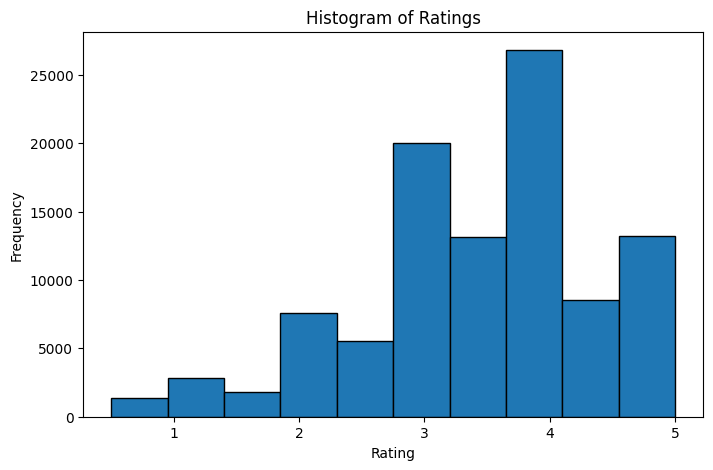

In [ ]:
#histogram of ratings
plt.figure(figsize=(8,5))

movie_data['rating'].hist(
    bins=10,
    edgecolor='black'
)

plt.title("Histogram of Ratings")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(False)

plt.show()

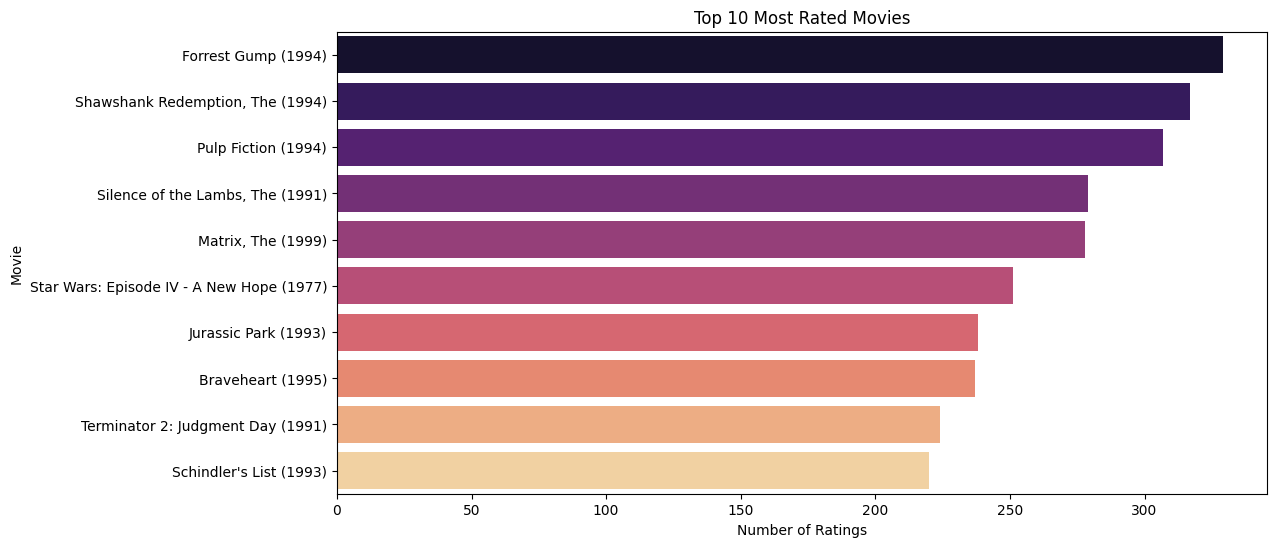

In [ ]:
#top 10 most rated movies

movie_rating_count = movie_data.groupby('title')['rating'].count().sort_values(ascending=False)
top_movies=movie_rating_count.head(10)
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_movies.values,
    y=top_movies.index,
    palette="magma"
)

plt.title("Top 10 Most Rated Movies")

plt.xlabel("Number of Ratings")

plt.ylabel("Movie")

plt.show()

In [ ]:
#ratings given by the user
user_rating_count = movie_data.groupby('userId')['rating'].count()

user_rating_count.describe()

,rating
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


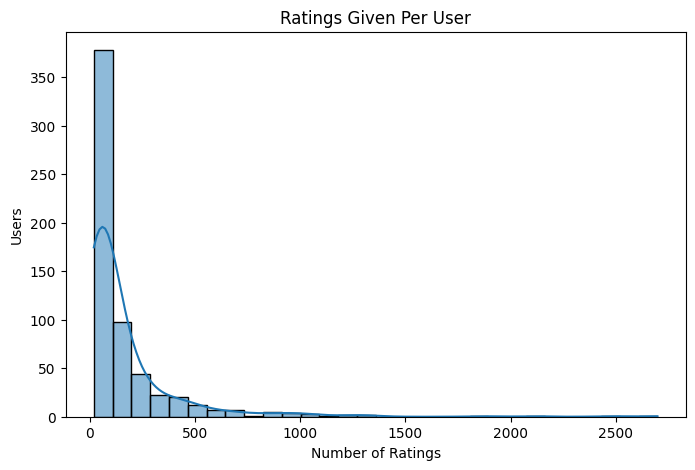

In [ ]:
#plot the distribtuion given by the user
plt.figure(figsize=(8,5))

sns.histplot(
    user_rating_count,
    bins=30,
    kde=True
)

plt.title("Ratings Given Per User")

plt.xlabel("Number of Ratings")

plt.ylabel("Users")

plt.show()

In [ ]:
movie_average=movie_data.groupby('title')['rating'].mean()
movie_average.sort_values(ascending=False).head(10)

,rating
title,
Karlson Returns (1970),5.0
Zeitgeist: Moving Forward (2011),5.0
"Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)",5.0
Dragons: Gift of the Night Fury (2011),5.0
12 Angry Men (1997),5.0
Justice League: Doom (2012),5.0
Junior and Karlson (1968),5.0
Jump In! (2007),5.0
"Human Condition III, The (Ningen no joken III) (1961)",5.0


In [ ]:
#movie statistics
movie_stats = movie_data.groupby('title').agg(
    Average_Rating=('rating','mean'),
    Number_of_Ratings=('rating','count')
)

movie_stats.head()

,Average_Rating,Number_of_Ratings
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [ ]:
popular_movies = movie_stats[
    movie_stats['Number_of_Ratings'] >= 100
].sort_values(
    by='Average_Rating',
    ascending=False
)

popular_movies.head(10)

,Average_Rating,Number_of_Ratings
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126
Casablanca (1942),4.240000,100
"Dark Knight, The (2008)",4.238255,149
"Usual Suspects, The (1995)",4.237745,204


In [ ]:
movie_stats.sort_values(
    by=["Average_Rating","Number_of_Ratings"],
    ascending=False
).head(20)

,Average_Rating,Number_of_Ratings
title,,
Belle époque (1992),5.0,2
Come and See (Idi i smotri) (1985),5.0,2
Enter the Void (2009),5.0,2
Heidi Fleiss: Hollywood Madam (1995),5.0,2
Jonah Who Will Be 25 in the Year 2000 (Jonas qui aura 25 ans en l'an 2000) (1976),5.0,2
Lamerica (1994),5.0,2
Lesson Faust (1994),5.0,2
'Salem's Lot (2004),5.0,1
12 Angry Men (1997),5.0,1


In [ ]:
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Data Preprocessing & KNN Model

In [ ]:
#Remove Movies with Very Few Ratings

# Count ratings for each movie
movie_rating_counts = movie_data.groupby('title')['rating'].count()

popular_movies = movie_rating_counts[movie_rating_counts >= 20]

filtered_movie_data = movie_data[
    movie_data['title'].isin(popular_movies.index)
]

In [ ]:
#remove inactive users
# Count ratings per user
user_rating_counts = filtered_movie_data.groupby('userId')['rating'].count()

# Keep users with at least 20 ratings
active_users = user_rating_counts[user_rating_counts >= 20]

filtered_movie_data = filtered_movie_data[
    filtered_movie_data['userId'].isin(active_users.index)
]


#Create User–Movie Matrix

In [ ]:
#rows-movies
#columns=user
#values-ratings
movie_user_matrix = filtered_movie_data.pivot_table(
    index='title',
    columns='userId',
    values='rating'
)

movie_user_matrix.head()


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5
10 Things I Hate About You (1999),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN
101 Dalmatians (1996),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN
101 Dalmatians (One Hundred and One Dalmatians) (1961),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12 Angry Men (1957),NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
movie_user_matrix.fillna(0, inplace=True)

movie_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5
10 Things I Hate About You (1999),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
101 Dalmatians (1996),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
101 Dalmatians (One Hundred and One Dalmatians) (1961),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(movie_user_matrix.shape)

(1297, 566)


In [ ]:
#convert this empty matrix into sparse matrix
from scipy.sparse import csr_matrix

movie_sparse_matrix = csr_matrix(movie_user_matrix.values)

print(movie_sparse_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 67225 stored elements and shape (1297, 566)>
  Coords	Values
  (0, 14)	4.0
  (0, 17)	4.0
  (0, 21)	0.5
  (0, 40)	3.5
  (0, 60)	4.5
  (0, 66)	4.0
  (0, 68)	4.0
  (0, 71)	4.0
  (0, 85)	2.5
  (0, 100)	5.0
  (0, 119)	1.0
  (0, 134)	3.0
  (0, 136)	5.0
  (0, 141)	3.5
  (0, 146)	3.5
  (0, 150)	5.0
  (0, 166)	3.5
  (0, 201)	4.5
  (0, 219)	5.0
  (0, 235)	4.0
  (0, 265)	4.0
  (0, 279)	2.0
  (0, 298)	3.0
  (0, 299)	4.0
  (0, 309)	4.0
  :	:
  (1296, 18)	2.0
  (1296, 26)	5.0
  (1296, 41)	5.0
  (1296, 55)	2.0
  (1296, 66)	4.0
  (1296, 84)	3.5
  (1296, 134)	3.5
  (1296, 187)	2.0
  (1296, 202)	2.5
  (1296, 204)	2.0
  (1296, 208)	3.5
  (1296, 226)	3.0
  (1296, 266)	4.0
  (1296, 276)	4.0
  (1296, 288)	2.5
  (1296, 294)	1.0
  (1296, 387)	3.0
  (1296, 394)	3.0
  (1296, 420)	3.0
  (1296, 445)	3.0
  (1296, 448)	3.5
  (1296, 515)	3.0
  (1296, 521)	4.0
  (1296, 553)	3.0
  (1296, 554)	2.5


#Train the KNN model

In [ ]:
knn_model=NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=11,
    n_jobs=-1)
knn_model.fit(
movie_sparse_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=11)

In [ ]:
movie_user_matrix.index[:20]

Index(['(500) Days of Summer (2009)', '10 Things I Hate About You (1999)',
       '101 Dalmatians (1996)',
       '101 Dalmatians (One Hundred and One Dalmatians) (1961)',
       '12 Angry Men (1957)', '13 Going on 30 (2004)',
       '13th Warrior, The (1999)', '1408 (2007)',
       '2001: A Space Odyssey (1968)', '2012 (2009)', '21 Grams (2003)',
       '21 Jump Street (2012)', '25th Hour (2002)', '27 Dresses (2008)',
       '28 Days (2000)', '28 Days Later (2002)', '28 Weeks Later (2007)',
       '300 (2007)', '3:10 to Yuma (2007)', '40-Year-Old Virgin, The (2005)'],
      dtype='object', name='title')

In [ ]:
def search_movie(keyword):
    keyword = keyword.lower()

    results = [
        movie
        for movie in movie_user_matrix.index
        if keyword in movie.lower()
    ]

    return results[:20]

In [ ]:
search_movie("batman")

['Batman & Robin (1997)',
 'Batman (1989)',
 'Batman Begins (2005)',
 'Batman Forever (1995)',
 'Batman Returns (1992)']

In [ ]:
def recommend_movies(movie_name, n_recommendations=10):

    if movie_name not in movie_user_matrix.index:
        print("Movie not found!")
        return

    movie_index = movie_user_matrix.index.get_loc(movie_name)

    distances, indices = knn_model.kneighbors(
        movie_user_matrix.iloc[movie_index, :].values.reshape(1, -1),
        n_neighbors=n_recommendations + 1
    )

    print("=" * 60)
    print("Selected Movie:")
    print(movie_name)
    print("=" * 60)

    print("\nRecommended Movies:\n")

    for i in range(1, len(distances.flatten())):
        print(
            f"{i}. {movie_user_matrix.index[indices.flatten()[i]]}"
            f"   (Distance = {distances.flatten()[i]:.3f})"
        )

In [ ]:
recommend_movies("Toy Story (1995)")

Selected Movie:
Toy Story (1995)

Recommended Movies:

1. Toy Story 2 (1999)   (Distance = 0.422)
2. Jurassic Park (1993)   (Distance = 0.429)
3. Star Wars: Episode IV - A New Hope (1977)   (Distance = 0.435)
4. Independence Day (a.k.a. ID4) (1996)   (Distance = 0.435)
5. Forrest Gump (1994)   (Distance = 0.447)
6. Star Wars: Episode VI - Return of the Jedi (1983)   (Distance = 0.455)
7. Lion King, The (1994)   (Distance = 0.457)
8. Mission: Impossible (1996)   (Distance = 0.462)
9. Groundhog Day (1993)   (Distance = 0.464)
10. Shrek (2001)   (Distance = 0.464)


In [ ]:
recommend_movies("Matrix, The (1999)")

Selected Movie:
Matrix, The (1999)

Recommended Movies:

1. Fight Club (1999)   (Distance = 0.283)
2. Star Wars: Episode V - The Empire Strikes Back (1980)   (Distance = 0.297)
3. Saving Private Ryan (1998)   (Distance = 0.318)
4. Star Wars: Episode IV - A New Hope (1977)   (Distance = 0.329)
5. Star Wars: Episode VI - Return of the Jedi (1983)   (Distance = 0.332)
6. Lord of the Rings: The Fellowship of the Ring, The (2001)   (Distance = 0.335)
7. Sixth Sense, The (1999)   (Distance = 0.345)
8. Lord of the Rings: The Return of the King, The (2003)   (Distance = 0.352)
9. Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)   (Distance = 0.362)
10. Gladiator (2000)   (Distance = 0.368)
